# Object-Tracking: Objekte eindeutig identifizieren und verfolgen

Bisher haben wir uns Inferenzen zu einzelnen Frames angesehen, und uns dabei einige
Fähigkeiten der Computer Vision genauer angeschaut - z.B. Objekterkennung (-detektion), 
Bildklassifikation, Pose Estimation, etc. 

Im tatsächlichen Anwendungsfall ist es allerdings oft nötig, sich nicht nur einzelne 
Bilder (Frames) anzusehen, sondern, wie im Fall von Verkehrsaufnahmen oder Security Tapes,
ein ganzes Video (d.h., viele Frames im zeitlichen Kontext) zu bewerten. 

Als kleine, finale Demonstration für Objektverfolgung nutzen wir hier nun **DeepSort**,
einen Object-Tracking Algorithmus der sowohl die dynamische Information ("Um wieviel
überlappen sich die Bounding Boxes meines Objekts vom einen Frame zum nächsten?"), als
auch die visuelle Information ("Passt das aussehen des Objekts im einen Frame zum Aussehen
im nächsten?") zur Objektverfolgung nutzt.

Zunächst sehen wir uns aber an wie man ein Video lädt - wir nutzen dazu erneut **opencv-python**.

## Für Colab...

In [ ]:
# relevante Packages installieren...
!pip -q install ultralytics opencv-python matplotlib numpy

# drive mounten, damit wir auf die Bilder/Videos zugreifen können
from google.colab import drive
drive.mount('/content/drive')

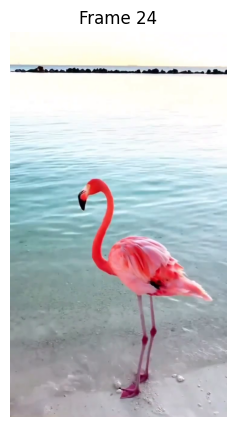

In [ ]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# für Colab: 
# video_path = "/content/drive/MyDrive/DIH-CV-main/videos/flamingo.mp4"

video_path = "/home/u88m52/projects/DIH-CV/videos/flamingo.mp4"

cap = cv2.VideoCapture(video_path)
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(25):
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    ax.clear()  # vorheriges Frame löschen
    ax.imshow(frame_rgb)
    ax.axis('off')
    ax.set_title(f"Frame {i}")

    clear_output(wait=True)
    display(fig)
    time.sleep(0.05)

cap.release()
plt.close(fig)  # Figures am Ende löschen

## Objekterkennungsmodell laden und testen

Jetzt, da wir wissen, wie man auf einzelne Frames des Videos zugreift, können wir ein
Objekterkennungsmodell verwenden, um Objekte in unseren einzelnen Bildern zu identifizieren!
Wir werden wieder [YOLO11](https://docs.ultralytics.com/models/yolo11/) verwenden.

Probieren wir das nochmals schnell auf dem letzten Frame aus:


0: 640x384 1 bird, 143.8ms
Speed: 4.9ms preprocess, 143.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)


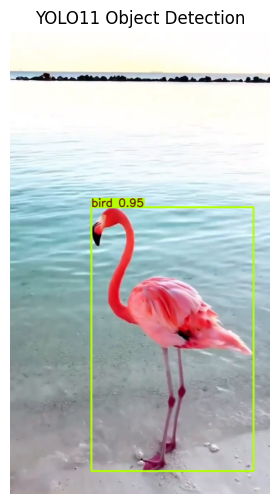

In [3]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("yolo11s.pt")
results = model(frame_rgb)

fig, ax = plt.subplots(figsize=(10, 6))
annotated_frame = results[0].plot()
ax.imshow(annotated_frame)
ax.axis('off')
ax.set_title("YOLO11 Object Detection")
plt.show()

## Objektverfolgung

Das Modell hat, wie erwartet, unseren Flamingo korrekt als Vogel erkannt - noch dazu mit
einer Genauigkeit von 95%. Die Ausgabe gibt uns Informationen über die Preprocessing-
und Inferenzzeiten sowie über die Dimensionen unseres Bildes (ein Bild, drei RGB-Kanäle
für Farbe und 640 × 384 Pixel).

Das Problem, allerdings? Wir können nun Boxen in einzelne Frames einzeichnen - das Modell
sieht allerdings immer nur ein Bild (stand-alone)!

Als nächster Schritt soll der Computer den Flamingo als ein einzelnes Objekt erkennen, das
sich von Frame zu Frame weiterbewegt – dafür nutzen wir die Objekt-Tracking-Funktionalitäten
von DeepSort.

Schauen wir es uns an!

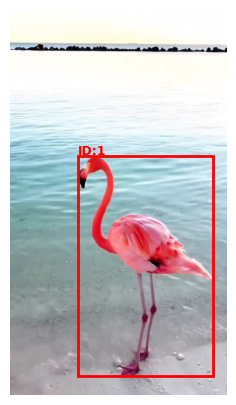

In [6]:
#!pip install deep_sort_realtime
from deep_sort_realtime.deepsort_tracker import DeepSort
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import numpy as np
import time

# den Tracker initialisieren...
tracker = DeepSort(max_age=30)
cap = cv2.VideoCapture(video_path)
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(25):
    ret, frame = cap.read()
    if not ret:
        break


    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = model(frame_rgb)  # your YOLOv8 model
    boxes = results[0].boxes.xyxy.cpu().numpy()
    scores = results[0].boxes.conf.cpu().numpy()

    detections = []
    for box, score in zip(boxes, scores):
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        detections.append([[x1, y1, width, height], float(score)])

    tracks = tracker.update_tracks(detections, frame=frame_rgb)

    ax.clear()
    ax.imshow(frame_rgb)
    ax.axis('off')

    for track in tracks:
        if not track.is_confirmed():
            continue
        x1, y1, width, height = track.original_ltwh # center point x/y, width, height
        track_id = track.track_id
        ax.add_patch(plt.Rectangle((x1, y1), width, height,
                                   fill=False, edgecolor='r', linewidth=2))
        ax.text(x1, y1-5, f'ID:{track_id}', color='r', fontsize=9, weight='bold')

    clear_output(wait=True)
    display(fig)
    time.sleep(0.05)

cap.release()
plt.close(fig)


## Tracking Informationen extrahieren und speichern...

Im Vergleich zu vorher sehen wir hier nun nicht mehr die Objektklasse und die dazugehörige
Konfidenz, sondern eine **vom Tracker zugewiesene ID**. Diese ID ist **statisch** über
alle Frames hinweg, da das Objekt (der Flamingo) als ein einziges sich bewegendes Objekt
erkannt wurde!

Als nächstes versuchen wir, einige Informationen zu unserem Objekt über alle Frames
hinweg zu extrahieren und abzuspeichern.

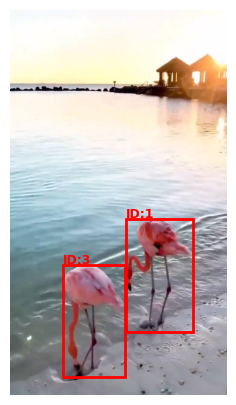

,frame,track_id,x_center,y_center
0,2,1,469.595581,875.916321
1,3,1,477.810944,858.168274
2,4,1,484.66745,849.017273
3,5,1,488.475342,836.627991
4,6,1,492.25296,834.035461


In [10]:
# !pip install pandas
from deep_sort_realtime.deepsort_tracker import DeepSort
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import numpy as np
import time
import pandas as pd

# den Tracker initialisieren
tracker = DeepSort(max_age=30)
cap = cv2.VideoCapture(video_path)
fig, ax = plt.subplots(figsize=(8, 5))

# ein DataFrame erstellen, um die Tracking-Informationen zu speichern
columns = ["frame", "track_id", "x_center", "y_center"]
df_tracks = pd.DataFrame(columns=columns)
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = model(frame_rgb)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    scores = results[0].boxes.conf.cpu().numpy()

    detections = []
    for box, score in zip(boxes, scores):
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        detections.append([[x1, y1, width, height], float(score)])

    tracks = tracker.update_tracks(detections, frame=frame_rgb)

    ax.clear()
    ax.imshow(frame_rgb)
    ax.axis('off')

    for track in tracks:
        if not track.is_confirmed():
            continue
        if track.original_ltwh is None:
            continue  # Tracks ohne bounding box Info übersprinbgen

        x1, y1, width, height = track.original_ltwh # Mittelpunkt x/y, Breite, Höhe
        track_id = track.track_id
        ax.add_patch(plt.Rectangle((x1, y1), width, height,
                                fill=False, edgecolor='r', linewidth=2))
        ax.text(x1, y1-5, f'ID:{track_id}', color='r', fontsize=9, weight='bold')

        x_center = x1 + width / 2
        y_center = y1 + height / 2
        df_tracks = pd.concat([df_tracks, pd.DataFrame([{
            "frame": frame_idx,
            "track_id": track_id,
            "x_center": x_center,
            "y_center": y_center
        }])], ignore_index=True)

    clear_output(wait=True)
    display(fig)
    time.sleep(0.01)
    frame_idx += 1

cap.release()
plt.close(fig)

df_tracks = df_tracks.astype({"frame": int, "track_id": int}) # sicherstellen, dass Frame und Track ID ganze Zahlen sind!
df_tracks.reset_index(drop=True, inplace=True) # sicherstellen, dass die Indizen nach dem Zusammenfügen noch zusammenpassen!
df_tracks.head() # die ersten fünf Zeilen anzeigen



In [ ]:
# alles speichern
import os

# für Colab: 
# save_path = "/content/drive/MyDrive/DIH-CV-main/videos/flamingo_test.mp4"

save_path = "/home/u88m52/projects/DIH-CV/videos"
os.makedirs(save_path, exist_ok=True)
tabulardata_path = os.path.join(save_path, "flamingo_object_tracks.csv")
df_tracks.to_csv(tabulardata_path, index=True)

Wir konnen hier nun - sogar mit zwei verschiedenen Objekten auf den Frames - genau zwischen
Objekt 1 und Objekt 3 (den beiden Flamingos) unterscheiden. Bei schwierigen Szenen, oder
auch im Fall von 'schlechteren' (kleineren) verwendeten Modellen, kann es zwischendurch
zu Fehlern im Tracking kommen. Hier wird dann oft einem Objekt fälschlicherweise eine 
neue Objekt-ID zugewiesen, obwohl es sich um ein bereits dokumentiertes Objekt handelt.

Sehen wir uns das in einem komplexeren Video genauer an...:

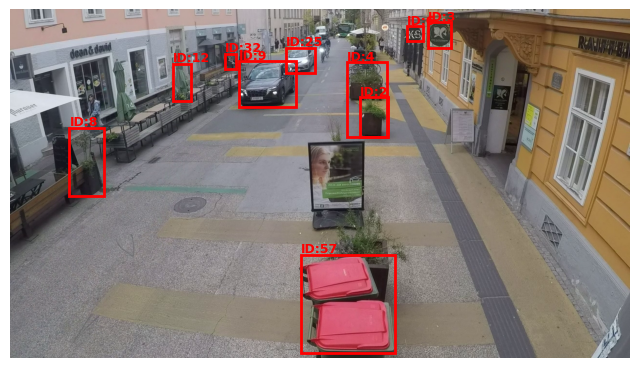

KeyboardInterrupt: 

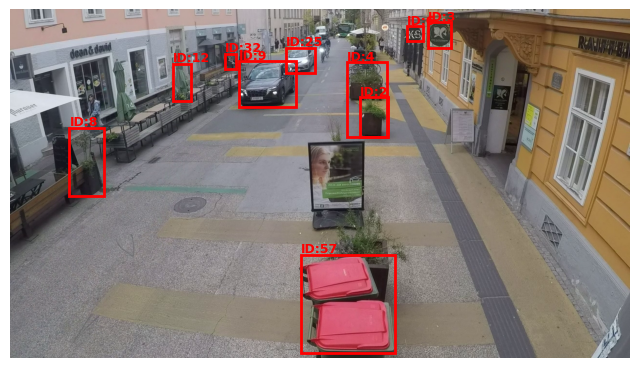

In [ ]:
# den Tracker initialisieren
tracker = DeepSort(max_age=30)

# für Colab: 
# video_path = "/content/drive/MyDrive/DIH-CV-main/videos/zinzendorfgasse_recording.mp4"
video_path = "/home/u88m52/projects/DIH-CV/videos/zinzendorfgasse_recording.mp4"
cap = cv2.VideoCapture(video_path)
fig, ax = plt.subplots(figsize=(8, 5))

# ein DataFrame erstellen, um die Tracking-Informationen zu speichern
columns = ["frame", "track_id", "x_center", "y_center"]
df_tracks = pd.DataFrame(columns=columns)
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % 10 == 0:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = model(frame_rgb)
        boxes = results[0].boxes.xyxy.cpu().numpy()
        scores = results[0].boxes.conf.cpu().numpy()

        detections = []
        for box, score in zip(boxes, scores):
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1
            detections.append([[x1, y1, width, height], float(score)])

        tracks = tracker.update_tracks(detections, frame=frame_rgb)

        ax.clear()
        ax.imshow(frame_rgb)
        ax.axis('off')

        for track in tracks:
            if not track.is_confirmed():
                continue
            if track.original_ltwh is None:
                continue  # Tracks ohne bounding box Info übersprinbgen

            x1, y1, width, height = track.original_ltwh # Mittelpunkt x/y, Breite, Höhe
            track_id = track.track_id
            ax.add_patch(plt.Rectangle((x1, y1), width, height,
                                    fill=False, edgecolor='r', linewidth=2))
            ax.text(x1, y1-5, f'ID:{track_id}', color='r', fontsize=9, weight='bold')

            x_center = x1 + width / 2
            y_center = y1 + height / 2
            df_tracks = pd.concat([df_tracks, pd.DataFrame([{
                "frame": frame_idx,
                "track_id": track_id,
                "x_center": x_center,
                "y_center": y_center
            }])], ignore_index=True)

        clear_output(wait=True)
        display(fig)
        time.sleep(0.01)
    frame_idx += 1

cap.release()
plt.close(fig)

df_tracks = df_tracks.astype({"frame": int, "track_id": int}) # sicherstellen, dass Frame und Track ID ganze Zahlen sind!
df_tracks.reset_index(drop=True, inplace=True) # sicherstellen, dass die Indizen nach dem Zusammenfügen noch zusammenpassen!
df_tracks.head() # die ersten fünf Zeilen anzeigen



Wie wir sehen, ist es in einem komplexeren Setting schon deutlich schwieriger für sowohl
das Objekterkennungsmodell, als auch den Tracker, die Objekte wahrheitsgetreu zu verfolgen.

**Eine kurze Anmerkung**
Das konkrete Beispiel (eine Verkehrsaufnahme der Zinzendorfgasse) zeigt auch ein weiteres
Problem in der Informationsextraktion aus Videos auf: die Perspektive der Kamera verzerrt
die Objekte teils sehr; hier die x- und y-Koordinaten zu extrahieren ist daher weitestgehend
bedeutungslos. In solchen Fällen ist es nötig, nach der Objektdetektion eine **Bird-Eye-View**
Transformation durchzuführen, die die Positionen der Objekte möglichst unverzerrt 'von
oben' darstellt. Diese Informationen können dann durchaus bedeutungsvoll extrahiert und
analysiert werden!


## Zusammenfassend...

Wir wissen jetzt:
- wie wir Videos mit **open-cv** laden können
- wie wir **DeepSort** verwenden können, um aus den Detektionen eines YOLO-Modells eindeutige
  IDs an Objekte zuzuweisen
- dass das i.A. (vor allem mit großen Modellen und 'cleanen' Videos) erstaunlich
  gut funktioniert, allerdings durchaus Fehlklassifikationen bzw. Fehlidentifikationen
  möglich sind und diese entsprechend gehandhabt werden müssen.